# Analyze GRPO Reward Learning

This notebook reads the GRPO trainer metrics log for a single run and plots reward trajectories over optimization steps.

It now covers two views:
- the full-training reward trajectory from `train_metrics.jsonl`
- config-specific reward trajectories from `reward_responses_rank*.jsonl`, joined back to the source training CSVs by prompt text when those logs are available


In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)


In [30]:
def resolve_existing_path(*candidates: str) -> Path:
    search_roots = [Path.cwd(), Path.cwd().parent, Path('/home/yuen_chen/ENCO')]
    for candidate in candidates:
        p = Path(candidate).expanduser()
        if p.exists():
            return p.resolve()
        for root in search_roots:
            q = (root / candidate).resolve()
            if q.exists():
                return q
    raise FileNotFoundError(f'Could not resolve any of: {candidates}')

train_metrics_path = resolve_existing_path(
    'experiments/checkpoints/grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_h200_vllm_colocate_2gpu_p4_colperm8/grpo_log/train_metrics.jsonl',
    'checkpoints/grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_h200_vllm_colocate_2gpu_p4_colperm8/grpo_log/train_metrics.jsonl',
)

# Update these to match the CSVs used for the run if you want config-specific plots.
source_train_csvs = [
    resolve_existing_path('experiments/data/grpo_mix_anon_no_cancer.csv', 'data/grpo_mix_anon_no_cancer.csv'),
    resolve_existing_path('experiments/data/grpo_mix_named_no_cancer.csv', 'data/grpo_mix_named_no_cancer.csv'),
]
output_dir = train_metrics_path.parent / 'reward_analysis'
output_dir.mkdir(parents=True, exist_ok=True)
reward_response_paths = sorted(train_metrics_path.parent.glob('reward_responses_rank*.jsonl'))
if train_metrics_path.parent.parent.name == 'grpo':
    run_name = train_metrics_path.parent.parent.parent.name
else:
    run_name = train_metrics_path.parent.parent.name
print('train_metrics_path =', train_metrics_path)
print('reward_response_logs =', len(reward_response_paths))
print('source_train_csvs =', [str(p) for p in source_train_csvs if p.exists()])
train_metrics_path


train_metrics_path = /home/yuen_chen/ENCO/experiments/checkpoints/grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_h200_vllm_colocate_2gpu_p4_colperm8/grpo_log/train_metrics.jsonl
reward_response_logs = 0
source_train_csvs = ['/home/yuen_chen/ENCO/experiments/data/grpo_mix_anon_no_cancer.csv', '/home/yuen_chen/ENCO/experiments/data/grpo_mix_named_no_cancer.csv']


PosixPath('/home/yuen_chen/ENCO/experiments/checkpoints/grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_h200_vllm_colocate_2gpu_p4_colperm8/grpo_log/train_metrics.jsonl')

In [31]:
df = pd.read_json(train_metrics_path, lines=True)

# Keep only per-step training rows; the final trainer summary row has runtime stats but no reward columns.
df = df[df['global_step'].notna()].copy()
df = df.sort_values('global_step').drop_duplicates(subset=['global_step'], keep='first').reset_index(drop=True)

reward_total_col = 'reward_total' if 'reward_total' in df.columns else 'reward'
graph_reward_mean_col = next((c for c in ['rewards/cd_graph_reward/mean', 'cd_graph_reward', 'graph_reward'] if c in df.columns), None)
reward_mean_cols = [c for c in df.columns if c.startswith('rewards/') and c.endswith('/mean')]
reward_std_cols = [c for c in df.columns if c.startswith('rewards/') and c.endswith('/std')]
positive_reward_cols = [col for col in reward_mean_cols if df[col].fillna(0).abs().max() > 0]
zero_reward_cols = [col for col in reward_mean_cols if col not in positive_reward_cols]

response_df = None
graph_traj = None
config_traj = None
graph_reward_response_col = None

if reward_response_paths:
    response_frames = [pd.read_json(path, lines=True) for path in reward_response_paths]
    response_df = pd.concat(response_frames, ignore_index=True)
    response_df = response_df[response_df['global_step'].notna()].copy()

    if 'rewards' in response_df.columns:
        rewards_expanded = pd.json_normalize(response_df['rewards']).add_prefix('reward_component/')
        response_df = pd.concat([response_df.drop(columns=['rewards']), rewards_expanded], axis=1)

    prompt_lookup_frames = []
    for csv_path in source_train_csvs:
        if not csv_path.exists():
            continue
        src = pd.read_csv(csv_path, usecols=lambda c: c in {'prompt_text', 'dataset', 'anonymize', 'prompt_style', 'obs_per_prompt', 'int_per_combo'})
        prompt_lookup_frames.append(src)

    if prompt_lookup_frames:
        prompt_lookup = pd.concat(prompt_lookup_frames, ignore_index=True)
        prompt_lookup = prompt_lookup.drop_duplicates(subset=['prompt_text'], keep='first')
        response_df = response_df.merge(prompt_lookup, left_on='prompt', right_on='prompt_text', how='left')
    else:
        response_df['dataset'] = pd.NA

    if 'dataset' not in response_df.columns:
        response_df['dataset'] = pd.NA

    named_graph = response_df['prompt'].astype(str).str.extract(r'Bayesian network named ([A-Za-z0-9_.-]+)', expand=False)
    response_df['dataset'] = response_df['dataset'].fillna(named_graph).fillna('unknown')

    graph_reward_response_col = next((c for c in ['reward_component/cd_graph_reward', 'cd_graph_reward'] if c in response_df.columns), None)

    agg = {'reward_total': 'mean'}
    if graph_reward_response_col is not None:
        agg[graph_reward_response_col] = 'mean'
    graph_traj = response_df.groupby(['global_step', 'dataset'], as_index=False).agg(agg)
    if graph_reward_response_col is not None:
        graph_traj = graph_traj.rename(columns={graph_reward_response_col: 'cd_graph_reward'})

    config_cols = ['dataset', 'anonymize', 'obs_per_prompt', 'int_per_combo']
    for col in config_cols:
        if col not in response_df.columns:
            response_df[col] = pd.NA
    response_df['config_label'] = (
        'graph=' + response_df['dataset'].fillna('unknown').astype(str)
        + ' | anon=' + response_df['anonymize'].astype(str)
        + ' | obs=' + response_df['obs_per_prompt'].astype(str)
        + ' | int=' + response_df['int_per_combo'].astype(str)
    )
    config_traj = response_df.groupby(['global_step', 'config_label'], as_index=False).agg(agg)
    if graph_reward_response_col is not None:
        config_traj = config_traj.rename(columns={graph_reward_response_col: 'cd_graph_reward'})

print(f'run: {run_name}')
print(f'train rows: {len(df)}')
print(f'full-training reward column: {reward_total_col}')
if graph_reward_mean_col:
    print(f'graph reward mean column: {graph_reward_mean_col}')
print('reward mean columns:')
for col in reward_mean_cols:
    print('  ', col)
if graph_traj is not None:
    print('graph-specific datasets:', sorted(graph_traj['dataset'].dropna().unique().tolist()))
if config_traj is not None:
    print('config-specific groups:', int(config_traj['config_label'].nunique()))

display(df.head())


run: grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_h200_vllm_colocate_2gpu_p4_colperm8
train rows: 91
full-training reward column: reward_total
graph reward mean column: rewards/cd_graph_reward/mean
reward mean columns:
   rewards/cd_format_reward/mean
   rewards/cd_edge_f1_reward/mean
   rewards/cd_low_shd_reward/mean
   rewards/cd_cot_structure_reward/mean
   rewards/cd_skeleton_f1_reward/mean
   rewards/cd_vstruct_f1_reward/mean
   rewards/cd_orientation_f1_reward/mean
   rewards/cd_graph_reward/mean


,global_step,epoch,time_unix,loss,grad_norm,learning_rate,num_tokens,completions/mean_length,completions/min_length,completions/max_length,completions/clipped_ratio,completions/mean_terminated_length,completions/min_terminated_length,completions/max_terminated_length,rewards/cd_format_reward/mean,rewards/cd_format_reward/std,rewards/cd_edge_f1_reward/mean,rewards/cd_edge_f1_reward/std,rewards/cd_low_shd_reward/mean,rewards/cd_low_shd_reward/std,rewards/cd_cot_structure_reward/mean,rewards/cd_cot_structure_reward/std,rewards/cd_skeleton_f1_reward/mean,rewards/cd_skeleton_f1_reward/std,rewards/cd_vstruct_f1_reward/mean,rewards/cd_vstruct_f1_reward/std,rewards/cd_orientation_f1_reward/mean,rewards/cd_orientation_f1_reward/std,rewards/cd_graph_reward/mean,rewards/cd_graph_reward/std,reward,reward_std,frac_reward_zero_std,sampling/sampling_logp_difference/mean,sampling/sampling_logp_difference/max,sampling/importance_sampling_ratio/min,sampling/importance_sampling_ratio/mean,sampling/importance_sampling_ratio/max,kl,entropy,clip_ratio/low_mean,clip_ratio/low_min,clip_ratio/high_mean,clip_ratio/high_max,clip_ratio/region_mean,metrics/raw_edge_f1,metrics/normalized_shd,reward_total
0,10,0.002315,1.776926e+09,3222.4350,65536.0,0.000005,435610,346.2250,266.8,467.8,1.0,0.0,0.0,0.0,0.044375,0.010479,0.069856,0.054996,0.135476,0.031654,0.046875,0.008839,0.040033,0.020909,0.010000,0.014056,0.021468,0.018076,0.098927,0.090209,0.467012,0.110508,0.20,0.066528,14.124730,0.001292,0.990087,2.0,64626.103769,0.019089,0,0,0,0,0,0.232854,0.322618,0.467012
1,20,0.004630,1.776926e+09,133.4401,1848.0,0.000005,878485,351.5375,279.9,438.4,1.0,0.0,0.0,0.0,0.048125,0.004082,0.103944,0.057189,0.156213,0.017369,0.048750,0.003536,0.049565,0.021283,0.020000,0.027439,0.036887,0.020542,0.159490,0.093287,0.622974,0.089452,0.05,0.066509,13.246625,0.000059,0.989497,2.0,2731.559651,0.019842,0,0,0,0,0,0.346480,0.218937,0.622974
2,30,0.006944,1.776926e+09,88.7890,532.0,0.000005,1393503,369.8250,247.7,565.4,1.0,0.0,0.0,0.0,0.043125,0.013067,0.069369,0.054690,0.140477,0.030337,0.045000,0.008985,0.038201,0.018465,0.011750,0.020913,0.020456,0.018848,0.099990,0.096794,0.468368,0.111440,0.05,0.070354,12.645793,0.000038,0.988353,2.0,2628.161079,0.021197,0,0,0,0,0,0.231230,0.297614,0.468368
3,40,0.009259,1.776927e+09,1445.8755,2704.0,0.000005,1992292,393.0125,250.7,567.3,1.0,0.0,0.0,0.0,0.044375,0.013468,0.087492,0.046926,0.149563,0.016453,0.045000,0.012921,0.044942,0.020757,0.009667,0.016140,0.025764,0.014956,0.127070,0.084895,0.533873,0.122527,0.05,0.058817,13.358137,0.000025,0.989585,2.0,22021.962319,0.022791,0,0,0,0,0,0.291640,0.252183,0.533873
4,50,0.011574,1.776928e+09,3897.0855,19.0,0.000005,2727741,448.5125,317.0,602.4,1.0,0.0,0.0,0.0,0.043125,0.014562,0.073465,0.055631,0.137209,0.037659,0.046875,0.007618,0.041480,0.016208,0.011000,0.016335,0.026283,0.019901,0.108691,0.095916,0.488128,0.147302,0.00,0.062749,12.199600,0.000297,0.988355,2.0,69487.549228,0.022714,0,0,0,0,0,0.244882,0.313953,0.488128


In [32]:
summary_cols = [
    'global_step',
    'epoch',
    reward_total_col,
    'reward_std',
    'frac_reward_zero_std',
    'completions/clipped_ratio',
    'kl',
    'entropy',
]
if graph_reward_mean_col:
    summary_cols.append(graph_reward_mean_col)
summary_cols += reward_mean_cols

df[[c for c in summary_cols if c in df.columns]]


,global_step,epoch,reward_total,reward_std,frac_reward_zero_std,completions/clipped_ratio,kl,entropy,rewards/cd_graph_reward/mean,rewards/cd_format_reward/mean,rewards/cd_edge_f1_reward/mean,rewards/cd_low_shd_reward/mean,rewards/cd_cot_structure_reward/mean,rewards/cd_skeleton_f1_reward/mean,rewards/cd_vstruct_f1_reward/mean,rewards/cd_orientation_f1_reward/mean,rewards/cd_graph_reward/mean
0,10,0.002315,0.467012,0.110508,0.20,1.0000,64626.103769,0.019089,0.098927,0.044375,0.069856,0.135476,0.046875,0.040033,0.010000,0.021468,0.098927
1,20,0.004630,0.622974,0.089452,0.05,1.0000,2731.559651,0.019842,0.159490,0.048125,0.103944,0.156213,0.048750,0.049565,0.020000,0.036887,0.159490
2,30,0.006944,0.468368,0.111440,0.05,1.0000,2628.161079,0.021197,0.099990,0.043125,0.069369,0.140477,0.045000,0.038201,0.011750,0.020456,0.099990
3,40,0.009259,0.533873,0.122527,0.05,1.0000,22021.962319,0.022791,0.127070,0.044375,0.087492,0.149563,0.045000,0.044942,0.009667,0.025764,0.127070
4,50,0.011574,0.488128,0.147302,0.00,1.0000,69487.549228,0.022714,0.108691,0.043125,0.073465,0.137209,0.046875,0.041480,0.011000,0.026283,0.108691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,870,0.201389,0.362670,0.179395,0.00,0.9750,0.186416,0.152441,0.065602,0.036875,0.056986,0.102950,0.038125,0.033905,0.009107,0.019120,0.065602
87,880,0.203704,0.553826,0.207915,0.00,1.0000,0.214799,0.127888,0.129228,0.041875,0.094412,0.128231,0.042500,0.051502,0.028333,0.037745,0.129228
88,890,0.206019,0.410544,0.225430,0.00,0.9750,0.191583,0.121688,0.073475,0.040625,0.062085,0.117464,0.040208,0.038009,0.018521,0.020156,0.073475
89,900,0.208333,0.375275,0.200392,0.00,0.9875,0.312596,0.162595,0.069651,0.035625,0.058291,0.107493,0.036667,0.035414,0.010833,0.021301,0.069651


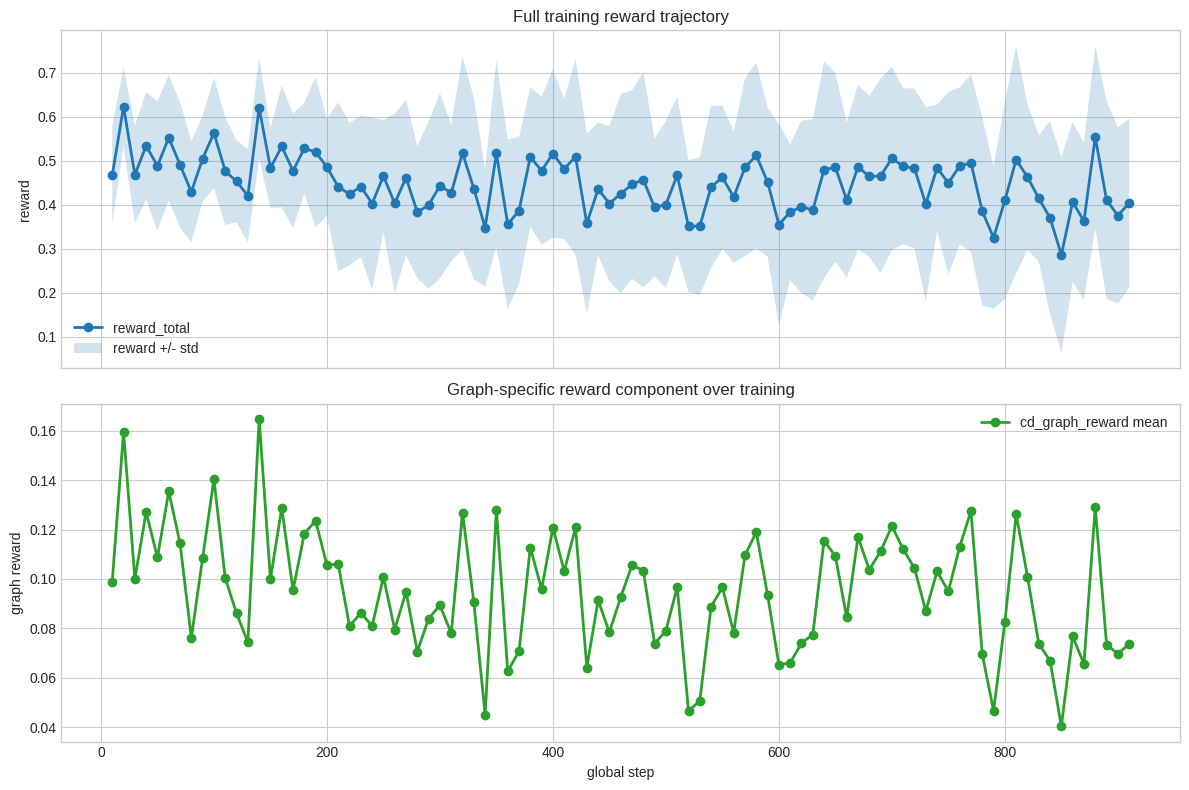

In [33]:
nrows = 2 if graph_reward_mean_col else 1
fig, axes = plt.subplots(nrows, 1, figsize=(12, 4 * nrows), sharex=True)
if nrows == 1:
    axes = [axes]

axes[0].plot(df['global_step'], df[reward_total_col], marker='o', linewidth=2, label=reward_total_col)
if 'reward_std' in df.columns:
    axes[0].fill_between(
        df['global_step'],
        df[reward_total_col] - df['reward_std'],
        df[reward_total_col] + df['reward_std'],
        alpha=0.2,
        label='reward +/- std',
    )
axes[0].set_ylabel('reward')
axes[0].set_title('Full training reward trajectory')
axes[0].legend(loc='best')

if graph_reward_mean_col:
    axes[1].plot(df['global_step'], df[graph_reward_mean_col], marker='o', linewidth=2, color='tab:green', label='cd_graph_reward mean')
    axes[1].set_ylabel('graph reward')
    axes[1].set_title('Graph-specific reward component over training')
    axes[1].legend(loc='best')

axes[-1].set_xlabel('global step')
plt.tight_layout()
fig.savefig(output_dir / 'reward_full_training_trajectory.png', dpi=160, bbox_inches='tight')
plt.show()


In [34]:
if config_traj is None or config_traj.empty:
    print('No config-specific reward trajectory available. Save reward_responses_rank*.jsonl for the run and point source_train_csvs at the matching training CSVs.')
else:
    has_graph_reward = 'cd_graph_reward' in config_traj.columns
    nrows = 2 if has_graph_reward else 1
    fig, axes = plt.subplots(nrows, 1, figsize=(12, 4 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]

    for config_label, part in config_traj.sort_values(['config_label', 'global_step']).groupby('config_label'):
        axes[0].plot(part['global_step'], part['reward_total'], marker='o', linewidth=2, label=config_label)
    axes[0].set_ylabel('mean reward_total')
    axes[0].set_title('Reward trajectory by training config')
    axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))

    if has_graph_reward:
        for config_label, part in config_traj.sort_values(['config_label', 'global_step']).groupby('config_label'):
            axes[1].plot(part['global_step'], part['cd_graph_reward'], marker='o', linewidth=2, label=config_label)
        axes[1].set_ylabel('mean cd_graph_reward')
        axes[1].set_title('Graph reward component by training config')
        axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))

    axes[-1].set_xlabel('global step')
    plt.tight_layout()
    fig.savefig(output_dir / 'reward_config_specific_trajectory.png', dpi=160, bbox_inches='tight')
    plt.show()

    display(config_traj.head())


No config-specific reward trajectory available. Save reward_responses_rank*.jsonl for the run and point source_train_csvs at the matching training CSVs.


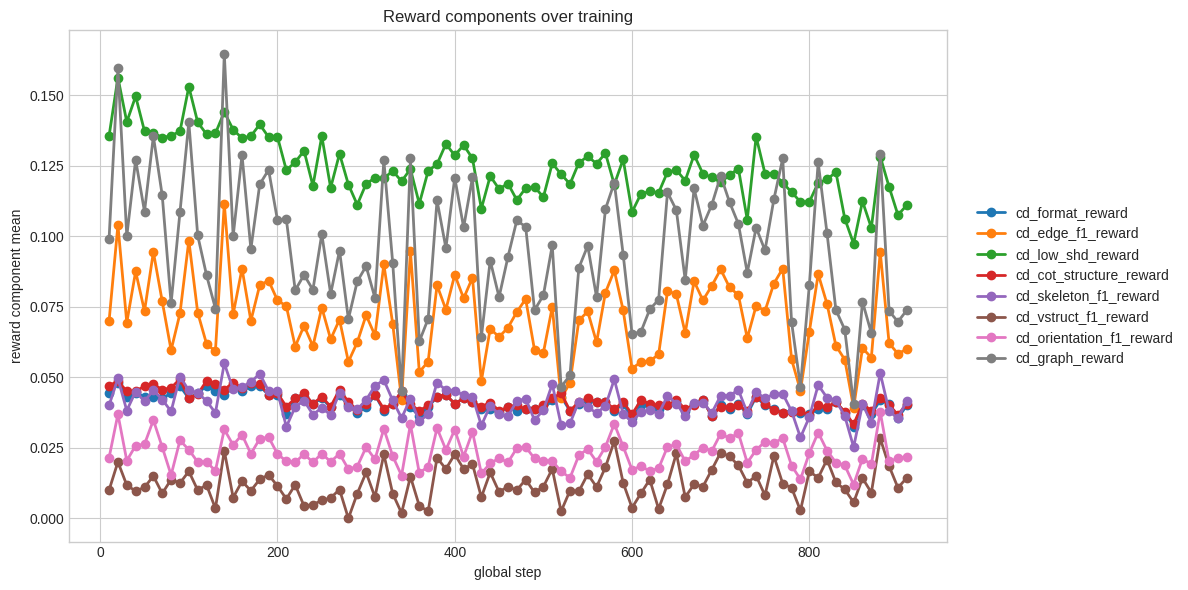

In [35]:
if reward_mean_cols:
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in reward_mean_cols:
        short = col.removeprefix('rewards/').removesuffix('/mean')
        ax.plot(df['global_step'], df[col], marker='o', linewidth=2, label=short)
    ax.set_xlabel('global step')
    ax.set_ylabel('reward component mean')
    ax.set_title('Reward components over training')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    fig.savefig(output_dir / 'all_reward_components.png', dpi=160, bbox_inches='tight')
else:
    print('No reward component mean columns found.')


In [36]:
positive_reward_cols = [col for col in reward_mean_cols if df[col].fillna(0).abs().max() > 0]
zero_reward_cols = [col for col in reward_mean_cols if col not in positive_reward_cols]

print('Reward components that moved:')
for col in positive_reward_cols:
    print('  ', col)

print('\nReward components that stayed at 0:')
for col in zero_reward_cols:
    print('  ', col)


Reward components that moved:
   rewards/cd_format_reward/mean
   rewards/cd_edge_f1_reward/mean
   rewards/cd_low_shd_reward/mean
   rewards/cd_cot_structure_reward/mean
   rewards/cd_skeleton_f1_reward/mean
   rewards/cd_vstruct_f1_reward/mean
   rewards/cd_orientation_f1_reward/mean
   rewards/cd_graph_reward/mean

Reward components that stayed at 0:


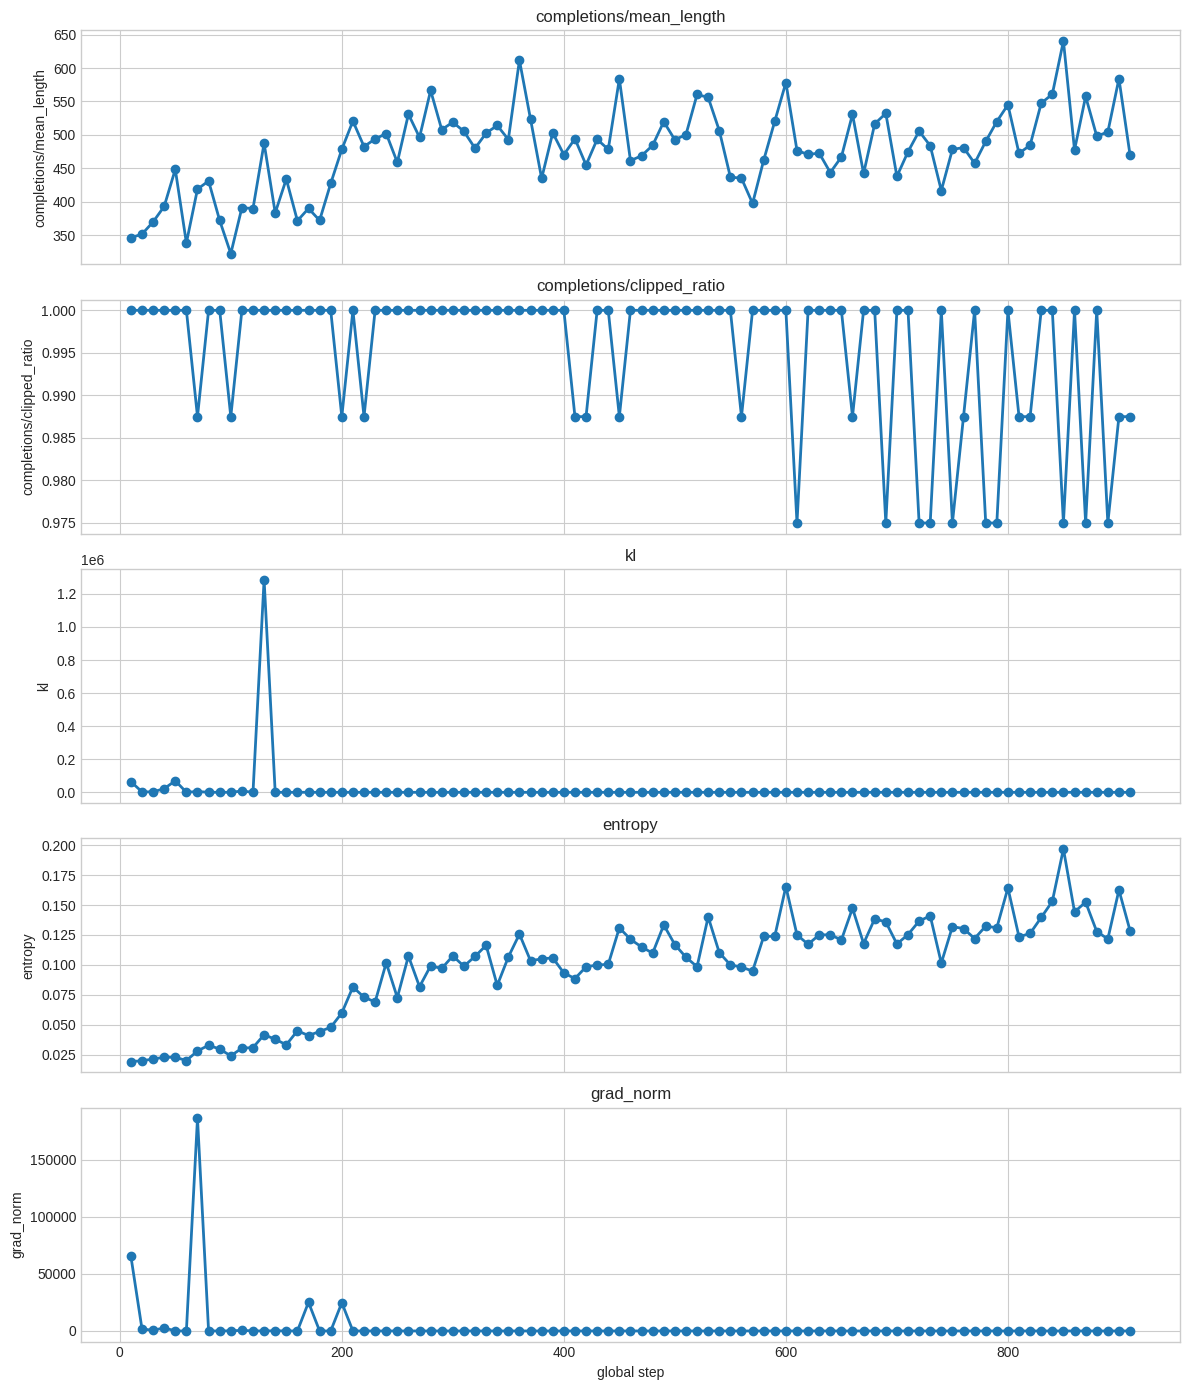

In [37]:
diagnostic_cols = [
    'completions/mean_length',
    'completions/clipped_ratio',
    'kl',
    'entropy',
    'grad_norm',
]

available_diagnostic_cols = [c for c in diagnostic_cols if c in df.columns]
n = len(available_diagnostic_cols)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.8 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, available_diagnostic_cols):
    ax.plot(df['global_step'], df[col], marker='o', linewidth=2)
    ax.set_ylabel(col)
    ax.set_title(col)

axes[-1].set_xlabel('global step')
plt.tight_layout()
fig.savefig(output_dir / 'diagnostics.png', dpi=160, bbox_inches='tight')


In [38]:
display_cols = ['global_step', 'reward', 'reward_std', 'frac_reward_zero_std'] + positive_reward_cols
df[display_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
global_step,91.0,460.000000,264.133804,10.000000,235.000000,460.000000,685.000000,910.000000
reward,91.0,0.449285,0.062226,0.285667,0.402850,0.453125,0.486755,0.622974
reward_std,91.0,0.173814,0.039860,0.089452,0.148369,0.177513,0.206402,0.258778
frac_reward_zero_std,91.0,0.027473,0.042337,0.000000,0.000000,0.000000,0.050000,0.200000
rewards/cd_format_reward/mean,91.0,0.040804,0.003012,0.032500,0.038750,0.040625,0.043125,0.048125
rewards/cd_edge_f1_reward/mean,91.0,0.070973,0.014120,0.039254,0.060593,0.071993,0.080293,0.111576
rewards/cd_low_shd_reward/mean,91.0,0.124199,0.010941,0.097313,0.117430,0.122706,0.132487,0.156213
rewards/cd_cot_structure_reward/mean,91.0,0.041600,0.003341,0.033333,0.039375,0.040625,0.043750,0.049375
rewards/cd_skeleton_f1_reward/mean,91.0,0.040990,0.005218,0.025235,0.037343,0.041402,0.044693,0.054948
rewards/cd_vstruct_f1_reward/mean,91.0,0.012491,0.005978,0.000000,0.008833,0.011815,0.016250,0.028333


In [39]:
window = min(10, len(df))
summary = pd.Series({
    'steps': int(len(df)),
    'reward_mean': df['reward'].mean(),
    'reward_min': df['reward'].min(),
    'reward_max': df['reward'].max(),
    'reward_first_window_mean': df['reward'].head(window).mean(),
    'reward_last_window_mean': df['reward'].tail(window).mean(),
    'best_step': int(df.loc[df['reward'].idxmax(), 'global_step']),
    'best_step_reward': df['reward'].max(),
})
summary


steps                       91.000000
reward_mean                  0.449285
reward_min                   0.285667
reward_max                   0.622974
reward_first_window_mean     0.512018
reward_last_window_mean      0.404466
best_step                   20.000000
best_step_reward             0.622974
dtype: float64

In [20]:
top_cols = ['global_step', 'reward', 'reward_std', 'frac_reward_zero_std'] + positive_reward_cols
df.nlargest(min(10, len(df)), 'reward')[top_cols]


,global_step,reward,reward_std,frac_reward_zero_std,rewards/cd_format_reward/mean,rewards/cd_edge_f1_reward/mean,rewards/cd_low_shd_reward/mean,rewards/cd_cot_structure_reward/mean,rewards/cd_skeleton_f1_reward/mean,rewards/cd_vstruct_f1_reward/mean,rewards/cd_orientation_f1_reward/mean,rewards/cd_graph_reward/mean
1,20,0.622974,0.089452,0.05,0.048125,0.103944,0.156213,0.048750,0.049565,0.020000,0.036887,0.159490
13,140,0.620046,0.115326,0.15,0.043750,0.111576,0.143976,0.045625,0.054948,0.023958,0.031503,0.164710
9,100,0.563080,0.125716,0.05,0.042500,0.098455,0.152956,0.042500,0.045345,0.016667,0.024317,0.140341
87,880,0.553826,0.207915,0.00,0.041875,0.094412,0.128231,0.042500,0.051502,0.028333,0.037745,0.129228
5,60,0.552330,0.142649,0.00,0.043125,0.094381,0.136695,0.047500,0.045388,0.015000,0.034813,0.135427
3,40,0.533873,0.122527,0.05,0.044375,0.087492,0.149563,0.045000,0.044942,0.009667,0.025764,0.127070
15,160,0.532604,0.138488,0.05,0.045000,0.088519,0.134723,0.046250,0.046552,0.013125,0.029654,0.128781
17,180,0.528304,0.103844,0.10,0.046875,0.082653,0.139600,0.047500,0.051272,0.013833,0.028192,0.118380
18,190,0.519631,0.171105,0.05,0.043750,0.084228,0.135109,0.043750,0.045109,0.015417,0.028763,0.123506
31,320,0.517664,0.219909,0.10,0.038125,0.089987,0.120449,0.038750,0.049038,0.022708,0.031755,0.126853


In [21]:
saved_plots = sorted(str(path.relative_to(train_metrics_path.parent)) for path in output_dir.glob('*.png'))
saved_plots


['reward_analysis/all_reward_components.png',
 'reward_analysis/diagnostics.png',
 'reward_analysis/reward_full_training_trajectory.png']

In [22]:
import json

path = "/u/chenyuen0103/ENCO/experiments/data/mixed_permuted_staged_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

print(len(rows))
print(rows[0].keys())

FileNotFoundError: [Errno 2] No such file or directory: '/u/chenyuen0103/ENCO/experiments/data/mixed_permuted_staged_sft.jsonl'

In [23]:
print(rows[0]['prompt'])

NameError: name 'rows' is not defined

In [24]:
import json

path = "/u/chenyuen0103/ENCO/experiments/data/permuted_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

print(len(rows))
print(rows[0].keys())
print(rows[0]['prompt'])

FileNotFoundError: [Errno 2] No such file or directory: '/u/chenyuen0103/ENCO/experiments/data/permuted_sft.jsonl'

In [25]:
print(rows[0]['answer'])

NameError: name 'rows' is not defined

In [26]:
import json
import re
from itertools import combinations

path = "/u/chenyuen0103/ENCO/experiments/data/permuted_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

print(f"Total records: {len(rows)}")

# ── Regexes ──────────────────────────────────────────────────────────────────
VAR_BLOCK_RE  = re.compile(r"--- VARIABLES ---\n(.*?)\n---", re.DOTALL)
VAR_LINE_RE   = re.compile(r"^\s*(\d+)\s*:\s*(\S+)", re.MULTILINE)
INT_KEY_RE    = re.compile(r"do\((\w+)=(\d+)\)")
ANSWER_RE     = re.compile(r"<answer>(.*?)</answer>", re.DOTALL)
STAGE1_RE     = re.compile(r"Stage 1 \(Skeleton\):\n(.*?)(?=\n\nStage|\Z)", re.DOTALL)
STAGE3_RE     = re.compile(r"Stage 3 \(Orientation\):\n(.*?)(?=</think>|\Z)", re.DOTALL)
INT_BLOCK_RE  = re.compile(r"interventional_data=\{(.*?)\}\s*\n---", re.DOTALL)

errors = []

for idx, row in enumerate(rows):
    prompt = row["prompt"]
    answer = row["answer"]

    # 1. VARIABLES block is sequential X1..Xn
    var_m = VAR_BLOCK_RE.search(prompt)
    if not var_m:
        errors.append(f"[{idx}] missing VARIABLES block")
        continue
    var_lines = VAR_LINE_RE.findall(var_m.group(1))  # [(pos, name), ...]
    for pos, name in var_lines:
        expected = f"X{int(pos)+1}"
        if name != expected:
            errors.append(f"[{idx}] VARIABLES pos {pos} is '{name}', expected '{expected}'")

    n = len(var_lines)

    # 2. Interventional keys use sequential Xi labels
    int_m = INT_BLOCK_RE.search(prompt)
    if int_m:
        for key_var, key_val in INT_KEY_RE.findall(int_m.group(1)):
            # key_var should be X1..Xn
            if not re.match(r"^X\d+$", key_var):
                errors.append(f"[{idx}] non-sequential int key: do({key_var}={key_val})")
            else:
                xi = int(key_var[1:])
                if xi < 1 or xi > n:
                    errors.append(f"[{idx}] int key {key_var} out of range [X1..X{n}]")

    # 3. Parse adjacency matrix from answer
    ans_m = ANSWER_RE.search(answer)
    if not ans_m:
        errors.append(f"[{idx}] missing <answer> block")
        continue
    try:
        adj = json.loads(ans_m.group(1))["adjacency_matrix"]
    except Exception as e:
        errors.append(f"[{idx}] failed to parse adj: {e}")
        continue

    # 4. Adj is NxN binary integers
    if len(adj) != n:
        errors.append(f"[{idx}] adj rows={len(adj)}, expected {n}")
    for i, row_vals in enumerate(adj):
        if len(row_vals) != n:
            errors.append(f"[{idx}] adj row {i} has {len(row_vals)} cols, expected {n}")
        for j, v in enumerate(row_vals):
            if not isinstance(v, int) or v not in (0, 1):
                errors.append(f"[{idx}] adj[{i}][{j}]={v!r} is not 0/1 int")

    # 5. Stage 3 directed edges match adjacency matrix
    s3_m = STAGE3_RE.search(answer)
    if s3_m:
        s3_text = s3_m.group(1).strip()
        stage3_edges = set()
        if s3_text != "None":
            for line in s3_text.splitlines():
                m = re.match(r"(X\d+)\s*->\s*(X\d+)", line.strip())
                if m:
                    i, j = int(m.group(1)[1:]) - 1, int(m.group(2)[1:]) - 1
                    stage3_edges.add((i, j))
        adj_edges = {(i, j) for i in range(n) for j in range(n) if adj[i][j] == 1}
        if stage3_edges != adj_edges:
            errors.append(f"[{idx}] Stage 3 edges {stage3_edges} != adj edges {adj_edges}")

    # 6. Stage 1 skeleton matches adj (undirected)
    s1_m = STAGE1_RE.search(answer)
    if s1_m:
        s1_text = s1_m.group(1).strip()
        stage1_edges = set()
        if s1_text != "None":
            for line in s1_text.splitlines():
                m = re.match(r"(X\d+)\s*--\s*(X\d+)", line.strip())
                if m:
                    i, j = int(m.group(1)[1:]) - 1, int(m.group(2)[1:]) - 1
                    stage1_edges.add(frozenset([i, j]))
        adj_skel = {frozenset([i, j])
                    for i in range(n) for j in range(i+1, n)
                    if adj[i][j] or adj[j][i]}
        if stage1_edges != adj_skel:
            errors.append(f"[{idx}] Stage 1 skeleton mismatch")

print(f"\nChecked {len(rows)} records")
if errors:
    print(f"ERRORS ({len(errors)}):")
    for e in errors[:20]:
        print(" ", e)
else:
    print("All checks passed ✓")


FileNotFoundError: [Errno 2] No such file or directory: '/u/chenyuen0103/ENCO/experiments/data/permuted_sft.jsonl'

In [27]:
import json, random
from pathlib import Path
from collections import defaultdict

path = Path("./data/permuted_sft.jsonl")
with open(path) as f:
    rows = [json.loads(l) for l in f if l.strip()]

# Group by graph
by_graph = defaultdict(list)
for r in rows:
    by_graph[r["graph"]].append(r)

rng = random.Random(42)

train, val, test = [], [], []

for graph, records in by_graph.items():
    rng.shuffle(records)
    if graph == "sachs":
        split = int(0.2 * len(records))
        val  += records[:split]
        test += records[split:]
    else:
        train += records

rng.shuffle(train)
rng.shuffle(val)

out = Path("./data")
for name, split in [("sft_train", train), ("sft_val", val), ("sft_test", test)]:
    p = out / f"{name}.jsonl"
    with open(p, "w") as f:
        for r in split:
            f.write(json.dumps(r) + "\n")
    print(f"{name}: {len(split)} records → {p}")


FileNotFoundError: [Errno 2] No such file or directory: 'data/permuted_sft.jsonl'

In [28]:
import json
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B-Thinking-2507")

splits = {
    "train": train,
    "val":   val,
    "test":  test,
}

for split_name, records in splits.items():
    lengths = [
        len(tok(r["prompt"] + r["answer"], add_special_tokens=False).input_ids)
        for r in records
    ]
    lengths.sort()
    n = len(lengths)
    print(f"\n{split_name} ({n} records)")
    print(f"  min    = {lengths[0]}")
    print(f"  p25    = {lengths[n//4]}")
    print(f"  median = {lengths[n//2]}")
    print(f"  p75    = {lengths[3*n//4]}")
    print(f"  p90    = {lengths[int(n*0.90)]}")
    print(f"  p95    = {lengths[int(n*0.95)]}")
    print(f"  p99    = {lengths[int(n*0.99)]}")
    print(f"  max    = {lengths[-1]}")
    print(f"  > 3000 = {sum(l > 3000 for l in lengths)} ({100*sum(l>3000 for l in lengths)/n:.1f}%)")
    print(f"  > 8192 = {sum(l > 8192 for l in lengths)} ({100*sum(l>8192 for l in lengths)/n:.1f}%)")


NameError: name 'train' is not defined

In [ ]:
import json

path = "/u/chenyuen0103/ENCO/experiments/data/descendant_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

print(len(rows))
print(rows[0].keys())
print(rows[0]['prompt'])

33000
dict_keys(['prompt', 'answer', 'graph', 'source', 'target', 'n_descendants'])
system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant is an expert in causal inference and reasons from empirical evidence to identify causal relationships.
user
TASK: For the intervention do(X7 = 1), identify which variables are descendants of X7.
The following are empirical summaries from an anonymized Bayesian network.
ASSUMPTIONS:
- The true graph is a DAG (no directed cycles).
- Interventions are perfect do-interventions (surgical): do(X=v) cuts all incoming edges into X.
- Only descendants of the intervened variable can change because of the intervention, up to sampling noise.

--- INTERVENTION SEMANTICS ---
- In do(X7 = 1), X7 is externally fixed.
- The intervention removes all incoming edges into X7.
- Downstream variables may change; upstream variables should not change because of this intervention.

--- VARIABLE ORDER ---
0: X1 s

In [ ]:
import json
from collections import Counter

path = "/u/chenyuen0103/ENCO/experiments/data/descendant_sft.jsonl"
with open(path, "r", encoding="utf-8") as f:
    rows = [json.loads(line) for line in f if line.strip()]

graph_counts = Counter(row["graph"] for row in rows)

print(len(rows))
print(graph_counts)

33000
Counter({'sachs': 15720, 'asia': 7680, 'earthquake': 4800, 'cancer': 4800})


In [ ]:
import json, random

with open("./data/descendant_sft.jsonl") as f:
    recs = [json.loads(l) for l in f]

train = [r for r in recs if r["graph"] in {"cancer", "earthquake", "asia"}]
sachs = [r for r in recs if r["graph"] == "sachs"]

rng = random.Random(42)
rng.shuffle(sachs)
mid = len(sachs) // 2
val, test = sachs[:mid], sachs[mid:]

rng.shuffle(train)

for split, path in [(train, "./data/desc_sft_train.jsonl"),
                    (val,   "./data/desc_sft_val.jsonl"),
                    (test,  "./data/desc_sft_test.jsonl")]:
    with open(path, "w") as f:
        for r in split:
            f.write(json.dumps(r) + "\n")
    print(f"{path}: {len(split)} records")


./data/desc_sft_train.jsonl: 17280 records
./data/desc_sft_val.jsonl: 7860 records
./data/desc_sft_test.jsonl: 7860 records


In [ ]:
import json
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B-Thinking-2507")

splits = {
    "train": train,
    "val":   val,
    "test":  test,
}

for split_name, records in splits.items():
    lengths = [
        len(tok(r["prompt"] + r["answer"], add_special_tokens=False).input_ids)
        for r in records
    ]
    lengths.sort()
    n = len(lengths)
    print(f"\n{split_name} ({n} records)")
    print(f"  min    = {lengths[0]}")
    print(f"  p25    = {lengths[n//4]}")
    print(f"  median = {lengths[n//2]}")
    print(f"  p75    = {lengths[3*n//4]}")
    print(f"  p90    = {lengths[int(n*0.90)]}")
    print(f"  p95    = {lengths[int(n*0.95)]}")
    print(f"  p99    = {lengths[int(n*0.99)]}")
    print(f"  max    = {lengths[-1]}")
    print(f"  > 3000 = {sum(l > 3000 for l in lengths)} ({100*sum(l>3000 for l in lengths)/n:.1f}%)")
    print(f"  > 8192 = {sum(l > 8192 for l in lengths)} ({100*sum(l>8192 for l in lengths)/n:.1f}%)")



train (17280 records)
  min    = 797
  p25    = 829
  median = 865
  p75    = 1073
  p90    = 1101
  p95    = 1132
  p99    = 1152
  max    = 1152
  > 3000 = 0 (0.0%)
  > 8192 = 0 (0.0%)

val (7860 records)
  min    = 1417
  p25    = 1450
  median = 1526
  p75    = 1596
  p90    = 1613
  p95    = 1620
  p99    = 1631
  max    = 1639
  > 3000 = 0 (0.0%)
  > 8192 = 0 (0.0%)

test (7860 records)
  min    = 1417
  p25    = 1450
  median = 1527
  p75    = 1597
  p90    = 1614
  p95    = 1621
  p99    = 1631
  max    = 1639
  > 3000 = 0 (0.0%)
  > 8192 = 0 (0.0%)


In [ ]:

import pandas as pd
from transformers import AutoTokenizer
import sys
sys.path.insert(0, "experiments")
from experiments.cd_generation.format import canonicalize_cd_prompt

# Match the settings from the launch command
# MODEL = "./checkpoints/mixed_staged_sft_v2"
MODEL = "Qwen/Qwen3-4B-Thinking-2507"
CSV   = "./data/cancer_randcol_seed43.csv"
TASK  = "causal_discovery"

tokenizer = AutoTokenizer.from_pretrained(MODEL, use_fast=True)

df = pd.read_csv(CSV)
raw = str(df.iloc[0]["prompt"])
prompt = canonicalize_cd_prompt(
    raw,
    task=TASK,
    wrap_system_prompt=True,
    append_format_hint=True,
    format_hint_text="",
    prefill_think=True,
)

ids = tokenizer(prompt, return_tensors="pt")["input_ids"][0]
decoded = tokenizer.decode(ids)  # keeps special tokens

print(f"\n[DEBUG] Token count: {len(ids)}")
print(f"[DEBUG] Last 500 chars of decoded:\n{decoded[-500:]}")
print(f"\n[DEBUG] First 500 chars of decoded:\n{decoded[:500]}")




[DEBUG] Token count: 1821
[DEBUG] Last 500 chars of decoded:
0,1.0]]}
}
Output: <think>[staged reasoning]</think><answer>{"adjacency_matrix": ...}</answer>
"adjacency_matrix": N×N 0/1 matrix in variable order. Must be a DAG.

Formatting requirement: Reason in three stages inside <think>: Stage 1 (Skeleton) - one "X -- Y" per line; Stage 2 (V-structures) - one "(parent1, collider, parent2)" per line; Stage 3 (Orientation) - one "X -> Y" per line. Write "None" for any empty stage. Then output: <answer>{"adjacency_matrix": [...]}</answer>.
assistant
<think>


[DEBUG] First 500 chars of decoded:
system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant reasons step by step inside <think> tags, following three explicit stages:
  Stage 1 (Skeleton): List each directly connected variable pair on its own line as "X -- Y". If none, write "None".
  Stage 2 (V-structures): List each unshielded collider as "(parent1, collider, parent2)"

In [2]:
import json
import csv

def jsonl_to_csv(jsonl_path, csv_path):
    """Convert JSONL to CSV format matching the target structure."""
    
    with open(jsonl_path, 'r') as f_in, open(csv_path, 'w', newline='') as f_out:
        fieldnames = [
            'dataset', 'bif_file', 'prompt_style', 'anonymize', 'obs_per_prompt',
            'int_per_combo', 'data_idx', 'shuffle_idx', 'given_edges', 'prompt_text', 'answer'
        ]
        writer = csv.DictWriter(f_out, fieldnames=fieldnames)
        writer.writeheader()
        
        for idx, line in enumerate(f_in):
            record = json.loads(line)
            
            # Extract graph name from source (e.g., "cancer_obs100_int10_anon_train" -> "cancer")
            source = record.get('source', '')
            dataset = source.split('_')[0] if source else record.get('graph', '')
            
            row = {
                'dataset': dataset,
                'bif_file': '',  # Not available in JSONL
                'prompt_style': 'step_by_step',  # Inferred from prompt structure
                'anonymize': 1,  # Default
                'obs_per_prompt': 100,  # Extract from prompt if possible
                'int_per_combo': 10,
                'data_idx': idx,
                'shuffle_idx': idx,
                'given_edges': '',
                'prompt_text': record.get('prompt', ''),
                'answer': record.get('answer', '')
            }
            writer.writerow(row)

# Usage with absolute paths
jsonl_to_csv('/u/chenyuen0103/ENCO/experiments/data/grpo_cancer_eq_seed99.jsonl', 
             '/u/chenyuen0103/ENCO/experiments/data/grpo_cancer_eq_seed99.csv')

In [4]:
import pandas as pd
df = pd.read_csv("/home/yuen_chen/ENCO/experiments/responses/sachs/qwen25_reasoning_guidance_eval_summary.csv")

In [5]:
df['model'].unique()

array(['Qwen2.5-14B-Instruct'], dtype=object)

In [15]:
df[df['valid_rows'] > 0].drop(columns=['response_csv', 'evaluated','num_rows', 'format_ok_rows','format_scored_rows'])
# drop all columns containing "ci95" 
df[df['valid_rows'] > 0].drop(columns=['response_csv', 'evaluated','num_rows'] + [c for c in df.columns if 'ci95' in c or 'consensus' in c or 'iqr' in c or 'precision' in c or 'recall' in c])

,dataset,model,obs_n,int_n,prompt_style,anonymize,valid_rows,format_scored_rows,format_ok_rows,format_rate,...,brier,brier_skeleton,var_shd_sd,var_accuracy_sd,var_f1_sd,var_num_pred_edges_sd,nhd_mean,nhd_sd,nhd_ratio_mean,nhd_ratio_sd
0,sachs,Qwen2.5-14B-Instruct,NaN,NaN,names_only,0,5,5,1,0.2,...,0.167636,0.298909,0.894427,8.131156e-03,0.006222,0.894427,0.160331,7.391960e-03,0.828870,6.222102e-03
1,sachs,Qwen2.5-14B-Instruct,NaN,NaN,names_only,0,5,5,0,0.0,...,0.172727,0.309091,0.000000,1.241267e-16,0.000000,0.000000,0.157025,0.000000e+00,0.826087,1.241267e-16
2,sachs,Qwen2.5-14B-Instruct,NaN,NaN,names_only,0,5,5,0,0.0,...,0.172727,0.309091,0.000000,1.241267e-16,0.000000,0.000000,0.157025,0.000000e+00,0.826087,1.241267e-16
6,sachs,Qwen2.5-14B-Instruct,0.0,50.0,summary,1,5,5,0,0.0,...,0.345455,0.690909,0.000000,0.000000e+00,0.000000,0.000000,0.314050,0.000000e+00,0.527778,0.000000e+00
7,sachs,Qwen2.5-14B-Instruct,0.0,50.0,summary,1,5,5,4,0.8,...,0.098182,0.196364,9.889388,8.990353e-02,0.016038,22.912878,0.168595,8.173048e-02,0.727778,2.487624e-01
8,sachs,Qwen2.5-14B-Instruct,0.0,50.0,summary,1,5,5,0,0.0,...,0.133455,0.266909,10.733126,9.757388e-02,0.157160,7.155418,0.163636,8.870352e-02,0.625840,1.571603e-01
21,sachs,Qwen2.5-14B-Instruct,100.0,50.0,matrix,1,3,5,0,0.0,...,0.160606,0.321212,11.789826,1.071802e-01,0.158215,8.544004,0.206612,9.743658e-02,0.688750,1.582153e-01
22,sachs,Qwen2.5-14B-Instruct,100.0,50.0,matrix,1,5,5,0,0.0,...,0.165091,0.329455,10.784248,9.803862e-02,0.148046,26.376126,0.251240,8.912601e-02,0.629894,1.480460e-01
23,sachs,Qwen2.5-14B-Instruct,100.0,50.0,summary,1,1,5,0,0.0,...,0.227273,0.454545,0.000000,0.000000e+00,0.000000,0.000000,0.206612,0.000000e+00,0.609756,0.000000e+00
24,sachs,Qwen2.5-14B-Instruct,100.0,50.0,matrix,1,5,5,1,0.2,...,0.136364,0.272727,0.000000,0.000000e+00,0.000000,0.000000,0.123967,0.000000e+00,0.555556,0.000000e+00


In [46]:
import pandas as pd
df = pd.read_csv("/home/yuen_chen/ENCO/experiments/responses/sachs/sachs_summary.csv")

In [50]:
df[df['model'] == "checkpoint-300_merged_vllm"]

,model,config,valid_rate,avg_F1,avg_shd,anonymize,append_format_hint,avg_FN,avg_FP,avg_TN,...,var_precision_sd,var_recall_ci95_high,var_recall_ci95_low,var_recall_iqr,var_recall_sd,var_shd_ci95_high,var_shd_ci95_low,var_shd_iqr,var_shd_sd,wrapper_mode
4,checkpoint-300_merged_vllm,"style=names_only,anon=0,reason=staged,row=rand...",0.0,NaN,NaN,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,plain
12,checkpoint-300_merged_vllm,"style=names_only,anon=0,reason=concise,row=ran...",0.0,NaN,NaN,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,plain
14,checkpoint-300_merged_vllm,"style=names_only,anon=0,reason=none,row=random...",0.0,NaN,NaN,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,plain
18,checkpoint-300_merged_vllm,"style=matrix,obs=0,int=200,shuf=1,anon=1,reaso...",0.6,0.264176,22.333333,1,0,13.000000,9.333333,83.666667,...,0.033628,0.235294,0.235294,0.000000,3.399350e-17,24.061891,20.604776,1.50,1.527525,plain
19,checkpoint-300_merged_vllm,"style=matrix,obs=0,int=200,shuf=1,anon=1,reaso...",0.0,NaN,NaN,1,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,plain
21,checkpoint-300_merged_vllm,"style=summary,obs=0,int=200,shuf=1,anon=1,reas...",0.0,NaN,NaN,1,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,plain
22,checkpoint-300_merged_vllm,"style=matrix,obs=0,int=200,shuf=1,anon=1,reaso...",0.6,0.444444,26.000000,1,0,15.000000,11.000000,82.000000,...,0.346410,0.348235,-0.112941,0.176471,2.037707e-01,36.912818,15.087182,9.00,9.643651,plain
24,checkpoint-300_merged_vllm,"style=summary,obs=0,int=200,shuf=1,anon=1,reas...",0.0,NaN,NaN,1,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,plain
26,checkpoint-300_merged_vllm,"style=summary,obs=0,int=200,shuf=1,anon=1,reas...",0.0,NaN,NaN,1,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,plain
49,checkpoint-300_merged_vllm,"style=matrix,obs=0,int=200,shuf=1,anon=0,reaso...",0.4,0.544410,14.000000,0,0,8.500000,5.500000,87.500000,...,0.029463,0.672941,0.327059,0.088235,1.247835e-01,15.960000,12.040000,1.00,1.414214,plain


In [48]:
df = pd.read_csv("/home/yuen_chen/ENCO/experiments/responses/sachs/sachs_summary.csv")
df[df["model"] == "checkpoint-300_merged_vllm"].groupby("reasoning_guidance")[["avg_f1", "consensus_f1", "avg_shd", "consensus_shd"]].mean()


,avg_f1,consensus_f1,avg_shd,consensus_shd
reasoning_guidance,,,,
concise,0.466882,0.308429,14.986111,14.833333
none,0.486609,0.452755,17.858333,15.666667
staged,0.461387,0.385092,17.607143,15.714286
